# Library Rentals Demand Prediction — Jeddah
## Full Data Science Project: From Raw Data to Machine Learning

**Estimated Time:** 2–3 hours

---

### Scenario

You are a data analyst at a chain of public libraries in Jeddah, Saudi Arabia. Management wants to predict how many book rentals each branch will get per hour so they can optimize staffing and inventory. They handed you a messy export from their system (`jeddah_library_rentals.csv`) containing hourly rental counts alongside weather data, branch information, and membership details.

### Your Job

1. Clean and explore the data
2. Engineer useful features
3. Build and compare **4 different ML models** to predict `Rentals_Count` (one of which must be a Neural Network)
4. Recommend the best model with justification

### Dataset Columns

- `Date` — Date of the record (DD/MM/YYYY)
- `Hour` — Hour of the day (0–23)
- `Rentals_Count` — **Target variable**, number of books rented that hour
- `Temperature_C` — Temperature in Celsius
- `Humidity_pct` — Humidity percentage
- `Wind_Speed_ms` — Wind speed in m/s
- `Visibility_m` — Visibility in meters
- `Solar_Radiation_MJm2` — Solar radiation (MJ/m²)
- `Rainfall_mm` — Rainfall in mm
- `Snowfall_cm` — Snowfall in cm
- `Season` — Season of the year
- `Holiday` — Whether it's a holiday (Yes/No)
- `Functioning_Day` — Whether the library was open (Yes/No)
- `Library_Branch` — Name of the library branch
- `Top_Category` — Most rented book category that hour
- `Membership_Type` — Dominant membership type
- `Day_of_Week` — Day name


---

# Part 1: Setup and Data Loading

**Tasks**

1. Import all required libraries
2. Load the dataset
3. Display the first and last 5 rows


In [ ]:
# TODO: Import libraries
# pandas, numpy, matplotlib.pyplot, seaborn
# From sklearn: train_test_split, StandardScaler, LabelEncoder
# From sklearn.metrics: mean_squared_error, mean_absolute_error, r2_score
# From sklearn.linear_model: LinearRegression
# From sklearn.tree: DecisionTreeRegressor
# From sklearn.ensemble: RandomForestRegressor
# From tensorflow.keras: Sequential, Dense
# warnings (to suppress warnings)
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import tensorflow as tf

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)


In [ ]:
# TODO: Load the CSV file into a DataFrame called df
df = pd.read_csv('jeddah_library_rentals.csv')
print("Loaded:", df.shape)


Loaded: (6609, 17)


In [ ]:
# TODO: Display first 5 rows
df.head()

,Date,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Season,Holiday,Functioning_Day,Library_Branch,Top_Category,Membership_Type,Day_of_Week
0,01/01/2023,9,51,21.7,40.6,5.0,1473.0,2.51,0.0,0,Winter,Yes,Yes,University Branch,History,Walk-in,Sunday
1,01/01/2023,10,44,25.3,70.2,7.0,1493.0,2.47,1.1,0,Winter,Yes,Yes,AL HAMRA BRANCH,Non-Fiction,Student,Sunday
2,01/01/2023,14,62,28.7,45.9,6.3,867.0,2.88,0.0,0,Winter,Yes,Yes,University Branch,Technology,Regular,Sunday
3,01/01/2023,16,91,26.9,NaN,5.2,1750.0,1.48,0.0,0,Winter,Yes,Yes,University Branch,Business,Premium,Sunday
4,01/01/2023,18,34,26.4,68.5,5.3,1531.0,0.53,0.0,0,Winter,Yes,Yes,Corniche Kiosk,Fiction,Premium,Sunday


In [ ]:
# TODO: Display last 5 rows
df.tail()

,Date,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm,Season,Holiday,Functioning_Day,Library_Branch,Top_Category,Membership_Type,Day_of_Week
6604,30/12/2024,14,28,25.3,65.6,2.3,1828.0,0.41,0.0,0,Winter,No,Yes,Al Hamra Branch,Science,Walk-in,Monday
6605,30/12/2024,17,73,22.3,62.9,6.6,1549.0,2.62,0.0,0,Winter,No,yes,Downtown Central,arabic literature,Walk-in,Monday
6606,30/12/2024,18,73,22.9,56.5,5.6,1769.0,0.75,0.0,0,Winter,No,Yes,University Branch,Children,Walk-in,Monday
6607,30/12/2024,19,70,22.1,60.2,5.6,1887.0,0.00,0.0,0,Winter,No,Yes,Downtown Central,Technology,Walk-in,Monday
6608,30/12/2024,20,28,18.5,66.9,3.4,1414.0,0.00,0.0,0,Winter,No,Yes,Al Hamra Branch,History,Regular,Monday


---

# Part 2: Data Inspection

**Tasks**

1. Check the shape of the dataset
2. Use `.info()` to see data types and non-null counts
3. Use `.describe()` to get statistical summary
4. Check for missing values per column
5. Check for duplicate rows


In [ ]:
# TODO: Print the shape of the DataFrame
print("Shape:", df.shape)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Shape: (6609, 17)
Rows: 6,609
Columns: 17


In [ ]:
# TODO: Print DataFrame info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  6585 non-null   object 
 1   Hour                  6609 non-null   int64  
 2   Rentals_Count         6609 non-null   int64  
 3   Temperature_C         6507 non-null   float64
 4   Humidity_pct          6532 non-null   float64
 5   Wind_Speed_ms         6536 non-null   float64
 6   Visibility_m          6552 non-null   float64
 7   Solar_Radiation_MJm2  6529 non-null   float64
 8   Rainfall_mm           6555 non-null   float64
 9   Snowfall_cm           6609 non-null   int64  
 10  Season                6467 non-null   object 
 11  Holiday               6596 non-null   object 
 12  Functioning_Day       6586 non-null   object 
 13  Library_Branch        6609 non-null   object 
 14  Top_Category          6609 non-null   object 
 15  Membership_Type      

In [ ]:
# TODO: Print statistical summary (describe)
df.describe()


,Hour,Rentals_Count,Temperature_C,Humidity_pct,Wind_Speed_ms,Visibility_m,Solar_Radiation_MJm2,Rainfall_mm,Snowfall_cm
count,6609.000000,6609.00000,6507.000000,6532.000000,6536.000000,6552.000000,6529.000000,6555.00000,6609.0
mean,15.029354,45.24966,31.739219,60.029501,4.236291,1398.750305,1.273552,0.14415,0.0
std,4.325237,24.13352,8.814169,11.949281,2.148673,348.831041,1.161596,0.68549,0.0
min,8.000000,-112.00000,-46.900000,35.600000,0.500000,800.000000,0.000000,0.00000,0.0
25%,11.000000,29.00000,27.100000,50.500000,2.400000,1093.750000,0.000000,0.00000,0.0
50%,15.000000,44.00000,32.100000,60.200000,4.200000,1401.000000,1.080000,0.00000,0.0
75%,19.000000,61.00000,36.900000,68.700000,6.100000,1700.000000,2.310000,0.00000,0.0
max,22.000000,125.00000,49.200000,94.600000,8.000000,2000.000000,3.500000,5.00000,0.0


In [ ]:
# TODO: Count missing values per column
df.isna().sum()

,0
Date,24
Hour,0
Rentals_Count,0
Temperature_C,102
Humidity_pct,77
Wind_Speed_ms,73
Visibility_m,57
Solar_Radiation_MJm2,80
Rainfall_mm,54
Snowfall_cm,0


In [ ]:
# TODO: Check how many duplicate rows exist
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 28


---

# Part 3: Data Cleaning

This is where the real work begins. The dataset has several issues to fix.

## 3.1 Fix the Date Column

**Tasks**

1. Convert `Date` to datetime using `pd.to_datetime()` with `errors='coerce'` and `dayfirst=True`
2. Check how many dates became `NaT` (failed to parse)
3. Drop rows where `Date` is `NaT`


In [ ]:
# TODO: Convert Date to datetime
# Hint: format is DD/MM/YYYY, so use dayfirst=True
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)

In [ ]:
# TODO: Print how many NaT values exist in Date
bad_dates = df['Date'].isna().sum()
print(f"Bad dates (NaT): {bad_dates}")


Bad dates (NaT): 37


In [ ]:
# TODO: Drop rows where Date is NaT, then verify
df = df.dropna(subset=['Date']).copy()
print("Rows after dropping bad dates:", len(df))


Rows after dropping bad dates: 6572


## 3.2 Fix Numeric Columns

**Tasks**

1. Convert weather columns to numeric using `pd.to_numeric()` with `errors='coerce'`
2. Replace any **negative** values in `Temperature_C` and `Rentals_Count` with `NaN` (Jeddah doesn't have negative temperatures, and negative rentals don't make sense)
3. Fill missing numeric values with the **median** of each column


In [ ]:
# Numeric columns to convert
numeric_cols = ['Temperature_C', 'Humidity_pct', 'Wind_Speed_ms',
                'Visibility_m', 'Solar_Radiation_MJm2', 'Rainfall_mm']

# TODO: Convert each to numeric with errors='coerce'
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion done. Dtypes:")
print(df[numeric_cols].dtypes)

Conversion done. Dtypes:
Temperature_C           float64
Humidity_pct            float64
Wind_Speed_ms           float64
Visibility_m            float64
Solar_Radiation_MJm2    float64
Rainfall_mm             float64
dtype: object


In [ ]:
# TODO: Replace negative Temperature_C values with NaN
neg_temp_count = (df['Temperature_C'] < 0).sum()
print(f"Negative temperatures found: {neg_temp_count}")
df.loc[df['Temperature_C'] < 0, 'Temperature_C'] = np.nan

Negative temperatures found: 52


In [ ]:
# TODO: Replace negative Rentals_Count values with NaN
neg_rentals = (df['Rentals_Count'] < 0).sum()
print(f"Negative rentals found: {neg_rentals}")
df.loc[df['Rentals_Count'] < 0, 'Rentals_Count'] = np.nan

Negative rentals found: 54


In [ ]:
# TODO: Fill missing numeric values with the median of each column
for col in numeric_cols + ['Rentals_Count']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled {col} with median = {median_val:.2f}")

Filled Temperature_C with median = 32.20
Filled Humidity_pct with median = 60.20
Filled Wind_Speed_ms with median = 4.20
Filled Visibility_m with median = 1399.00
Filled Solar_Radiation_MJm2 with median = 1.08
Filled Rainfall_mm with median = 0.00
Filled Rentals_Count with median = 44.00


In [ ]:
# Verify
print(df[numeric_cols + ['Rentals_Count']].describe())
print("\nMissing values remaining:")
print(df[numeric_cols + ['Rentals_Count']].isna().sum())


       Temperature_C  Humidity_pct  Wind_Speed_ms  Visibility_m  \
count    6572.000000   6572.000000    6572.000000   6572.000000   
mean       32.262386     60.038877       4.234875   1398.161442   
std         6.581977     11.877817       2.137222    347.462964   
min        16.600000     35.600000       0.500000    800.000000   
25%        27.400000     50.700000       2.400000   1095.000000   
50%        32.200000     60.200000       4.200000   1399.000000   
75%        36.800000     68.600000       6.100000   1697.250000   
max        49.200000     94.600000       8.000000   2000.000000   

       Solar_Radiation_MJm2  Rainfall_mm  Rentals_Count  
count           6572.000000  6572.000000    6572.000000  
mean               1.272063     0.142864      46.015064  
std                1.155546     0.682962      22.446051  
min                0.000000     0.000000       0.000000  
25%                0.000000     0.000000      30.000000  
50%                1.085000     0.000000      44

## 3.3 Standardize Text Columns

**Tasks**

1. For `Season`, `Library_Branch`, `Top_Category`, `Membership_Type`: strip whitespace and apply `.str.title()`
2. Fix inconsistent `Holiday` and `Functioning_Day` values — map all variations (`Y`, `yes`, `YES`) to `Yes` and (`N`, `no`, `NO`) to `No`
3. Fill any empty strings or remaining NaN in text columns with a sensible default
4. Print `.value_counts()` for each categorical column to verify


In [ ]:
# TODO: Clean Library_Branch (strip + title case)
df['Library_Branch'] = df['Library_Branch'].str.strip().str.title()
print(df['Library_Branch'].value_counts())

Library_Branch
Al Hamra Branch      1325
Downtown Central     1322
Al Rawdah Branch     1315
University Branch    1314
Corniche Kiosk       1296
Name: count, dtype: int64


In [ ]:
# TODO: Clean Top_Category (strip + title case)
df['Top_Category'] = df['Top_Category'].str.strip().str.title()
print(df['Top_Category'].value_counts())

Top_Category
History              868
Business             860
Arabic Literature    859
Science              821
Fiction              807
Non-Fiction          802
Children             791
Technology           764
Name: count, dtype: int64


In [ ]:
# TODO: Clean Season (strip + title case)
df['Season'] = df['Season'].str.strip().str.title()
print(df['Season'].value_counts(dropna=False))

Season
Autumn    1634
Summer    1619
Winter    1599
Spring    1578
NaN        142
Name: count, dtype: int64


In [ ]:
# TODO: Clean Membership_Type (strip + title case)
df['Membership_Type'] = df['Membership_Type'].str.strip().str.title()
print(df['Membership_Type'].value_counts(dropna=False))

Membership_Type
Walk-In    1643
Premium    1620
Regular    1610
Student    1590
NaN         109
Name: count, dtype: int64


In [ ]:
# TODO: Standardize Holiday column
# Hint: use .replace() or .map() to map 'Y', 'yes', 'YES' -> 'Yes' and 'N', 'no', 'NO' -> 'No'
yes_no_map = {
    'Y': 'Yes', 'Yes': 'Yes', 'yes': 'Yes', 'YES': 'Yes',
    'N': 'No',  'No': 'No',  'no': 'No',  'NO': 'No'
}
df['Holiday'] = df['Holiday'].map(yes_no_map)
print(df['Holiday'].value_counts(dropna=False))

Holiday
No     5288
Yes    1273
NaN      11
Name: count, dtype: int64


In [ ]:
# TODO: Standardize Functioning_Day column the same way
df['Functioning_Day'] = df['Functioning_Day'].map(yes_no_map)
print(df['Functioning_Day'].value_counts(dropna=False))

Functioning_Day
Yes    6372
No      177
NaN      23
Name: count, dtype: int64


In [ ]:
# TODO: Fill remaining empty strings or NaN in categorical columns with a default value
df['Season'] = df['Season'].replace('', np.nan).fillna('Unknown')
df['Membership_Type'] = df['Membership_Type'].replace('', np.nan).fillna('Regular')
df['Holiday'] = df['Holiday'].fillna('No')
df['Functioning_Day'] = df['Functioning_Day'].fillna('Yes')

In [ ]:
# Verify - print value counts for each
for col in ['Season', 'Holiday', 'Functioning_Day', 'Library_Branch', 'Top_Category', 'Membership_Type']:
    print(f"\n{col}:")
    print(df[col].value_counts())



Season:
Season
Autumn     1634
Summer     1619
Winter     1599
Spring     1578
Unknown     142
Name: count, dtype: int64

Holiday:
Holiday
No     5299
Yes    1273
Name: count, dtype: int64

Functioning_Day:
Functioning_Day
Yes    6395
No      177
Name: count, dtype: int64

Library_Branch:
Library_Branch
Al Hamra Branch      1325
Downtown Central     1322
Al Rawdah Branch     1315
University Branch    1314
Corniche Kiosk       1296
Name: count, dtype: int64

Top_Category:
Top_Category
History              868
Business             860
Arabic Literature    859
Science              821
Fiction              807
Non-Fiction          802
Children             791
Technology           764
Name: count, dtype: int64

Membership_Type:
Membership_Type
Regular    1719
Walk-In    1643
Premium    1620
Student    1590
Name: count, dtype: int64


## 3.4 Handle Remaining Issues

**Tasks**

1. Check whether `Snowfall_cm` is always 0 (Jeddah never gets snow), then drop that column
2. Remove duplicate rows
3. Filter out rows where `Functioning_Day == 'No'` (library was closed)
4. Reset the index


In [ ]:
# TODO: Check Snowfall_cm unique values
print("Unique Snowfall values:", df['Snowfall_cm'].unique())


Unique Snowfall values: [0]


In [ ]:
# TODO: Drop the Snowfall_cm column
df = df.drop(columns=['Snowfall_cm'])
print("Shape after dropping Snowfall_cm:", df.shape)

Shape after dropping Snowfall_cm: (6572, 16)


In [ ]:
# TODO: Remove duplicate rows
before = len(df)
df = df.drop_duplicates().copy()
print(f"Removed {before - len(df)} duplicate rows. New shape: {df.shape}")

Removed 28 duplicate rows. New shape: (6544, 16)


In [ ]:
# TODO: Filter out non-functioning days
before = len(df)
df = df[df['Functioning_Day'] == 'Yes'].copy()
print(f"Removed {before - len(df)} non-functioning rows. New shape: {df.shape}")

Removed 177 non-functioning rows. New shape: (6367, 16)


In [ ]:
# TODO: Reset index
df = df.reset_index(drop=True)

In [ ]:
# Verify final state
print("Final shape:", df.shape)
print("\nMissing values:")
print(df.isna().sum())
print("\nData types:")
print(df.dtypes)


Final shape: (6367, 16)

Missing values:
Date                    0
Hour                    0
Rentals_Count           0
Temperature_C           0
Humidity_pct            0
Wind_Speed_ms           0
Visibility_m            0
Solar_Radiation_MJm2    0
Rainfall_mm             0
Season                  0
Holiday                 0
Functioning_Day         0
Library_Branch          0
Top_Category            0
Membership_Type         0
Day_of_Week             0
dtype: int64

Data types:
Date                    datetime64[ns]
Hour                             int64
Rentals_Count                  float64
Temperature_C                  float64
Humidity_pct                   float64
Wind_Speed_ms                  float64
Visibility_m                   float64
Solar_Radiation_MJm2           float64
Rainfall_mm                    float64
Season                          object
Holiday                         object
Functioning_Day                 object
Library_Branch                  object
Top_Catego

---

# Part 4: Exploratory Data Analysis (EDA)

Now that the data is clean, let's understand it visually. Each plot should have a clear title and labelled axes.


## 4.1 Distribution of the Target Variable

**Task:** Plot a histogram of `Rentals_Count`. What does the shape tell you?


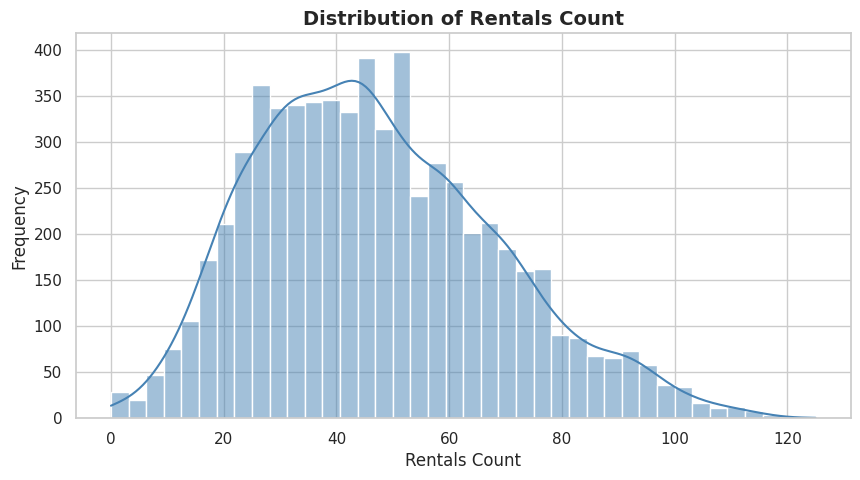

Mean: 47.15
Median: 45.00
Std: 21.51
Skew: 0.48


In [ ]:
# TODO: Plot histogram of Rentals_Count
# Use plt.figure(figsize=(10, 5)) and add title + xlabel + ylabel
plt.figure(figsize=(10, 5))
sns.histplot(df['Rentals_Count'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Rentals Count', fontsize=14, fontweight='bold')
plt.xlabel('Rentals Count')
plt.ylabel('Frequency')
plt.show()

print(f"Mean: {df['Rentals_Count'].mean():.2f}")
print(f"Median: {df['Rentals_Count'].median():.2f}")
print(f"Std: {df['Rentals_Count'].std():.2f}")
print(f"Skew: {df['Rentals_Count'].skew():.2f}")

## 4.2 Rentals by Hour

**Task:** Plot the average `Rentals_Count` by `Hour`. When are peak hours?


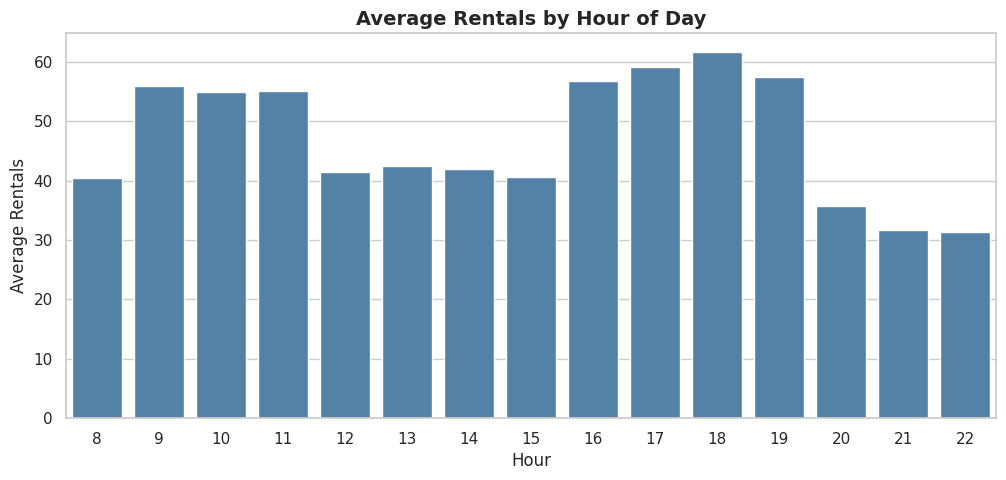

Peak hours: [18, 17, 19]


In [ ]:
# TODO: Group by Hour, calculate mean Rentals_Count, and plot
hourly = df.groupby('Hour')['Rentals_Count'].mean()

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly.index, y=hourly.values, color='steelblue')
plt.title('Average Rentals by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')
plt.show()

print("Peak hours:", hourly.sort_values(ascending=False).head(3).index.tolist())

## 4.3 Rentals by Season

**Task:** Boxplot of `Rentals_Count` grouped by `Season`. Which season has the highest variance?


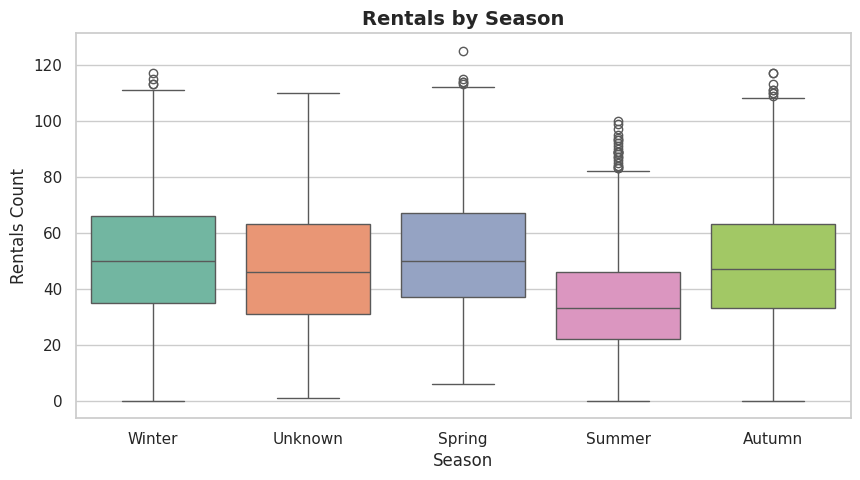

In [ ]:
# TODO: Boxplot of Rentals_Count by Season
plt.figure(figsize=(10, 5))
sns.boxplot(x='Season', y='Rentals_Count', data=df, palette='Set2')
plt.title('Rentals by Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Rentals Count')
plt.show()

## 4.4 Rentals by Library Branch

**Task:** Bar plot of total rentals per `Library_Branch`. Which branch is busiest?


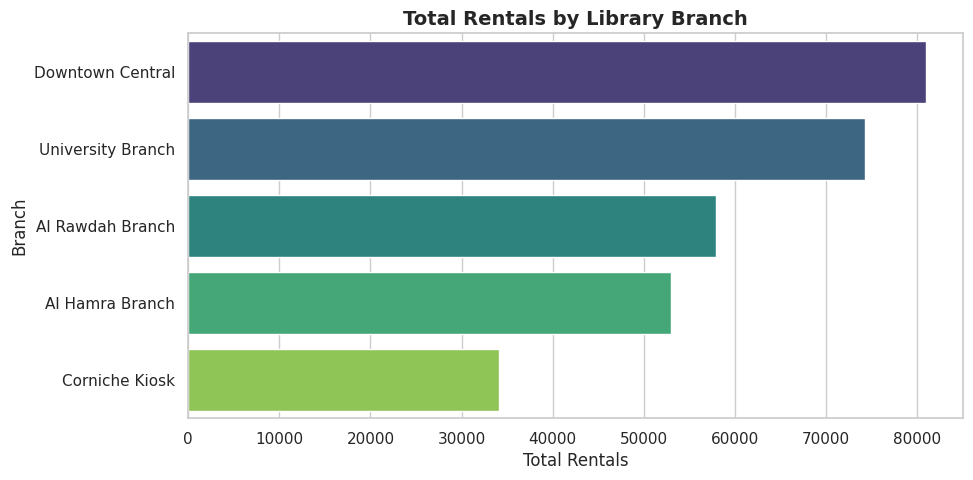

Busiest branch: Downtown Central


In [ ]:
# TODO: Bar plot of total Rentals_Count by Library_Branch
branch_totals = df.groupby('Library_Branch')['Rentals_Count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=branch_totals.values, y=branch_totals.index, palette='viridis')
plt.title('Total Rentals by Library Branch', fontsize=14, fontweight='bold')
plt.xlabel('Total Rentals')
plt.ylabel('Branch')
plt.show()

print("Busiest branch:", branch_totals.idxmax())

## 4.5 Correlation Heatmap

**Task:** Heatmap of correlations between all numeric columns. Which features correlate most with `Rentals_Count`?


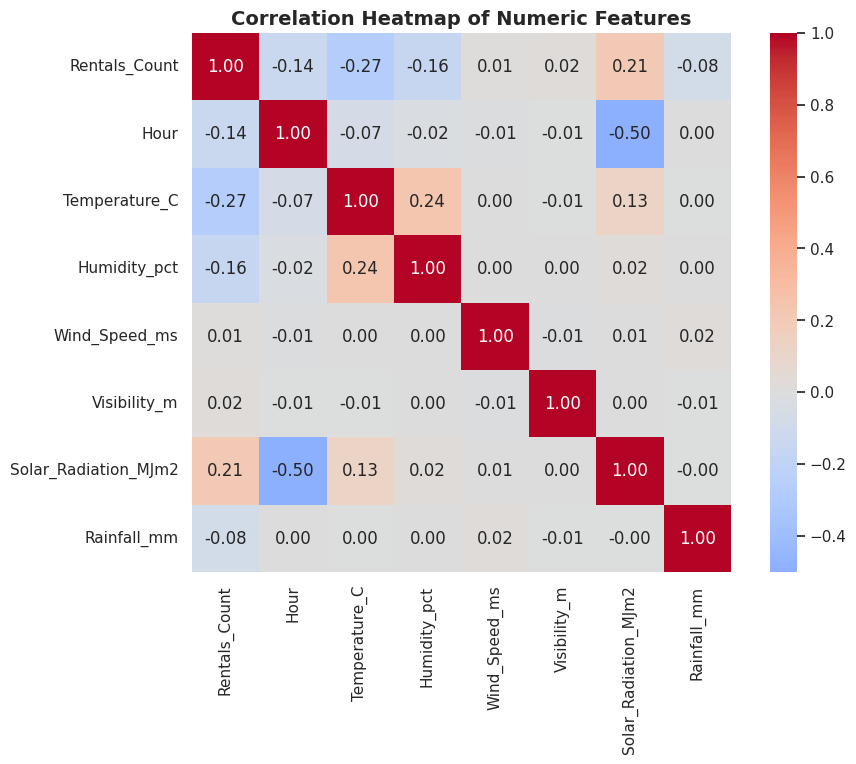

Top correlations with Rentals_Count:
Rentals_Count           1.000000
Temperature_C           0.272458
Solar_Radiation_MJm2    0.212664
Humidity_pct            0.156248
Hour                    0.137716
Rainfall_mm             0.081914
Visibility_m            0.016606
Wind_Speed_ms           0.010348
Name: Rentals_Count, dtype: float64


In [ ]:
# TODO: Compute correlation matrix and plot heatmap
# Use sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
numeric_for_corr = ['Rentals_Count', 'Hour', 'Temperature_C', 'Humidity_pct',
                    'Wind_Speed_ms', 'Visibility_m', 'Solar_Radiation_MJm2', 'Rainfall_mm']
corr = df[numeric_for_corr].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.show()

print("Top correlations with Rentals_Count:")
print(corr['Rentals_Count'].abs().sort_values(ascending=False))

## 4.6 Temperature vs Rentals

**Task:** Scatter plot of `Temperature_C` vs `Rentals_Count`, colored by `Season`. What relationship do you see?


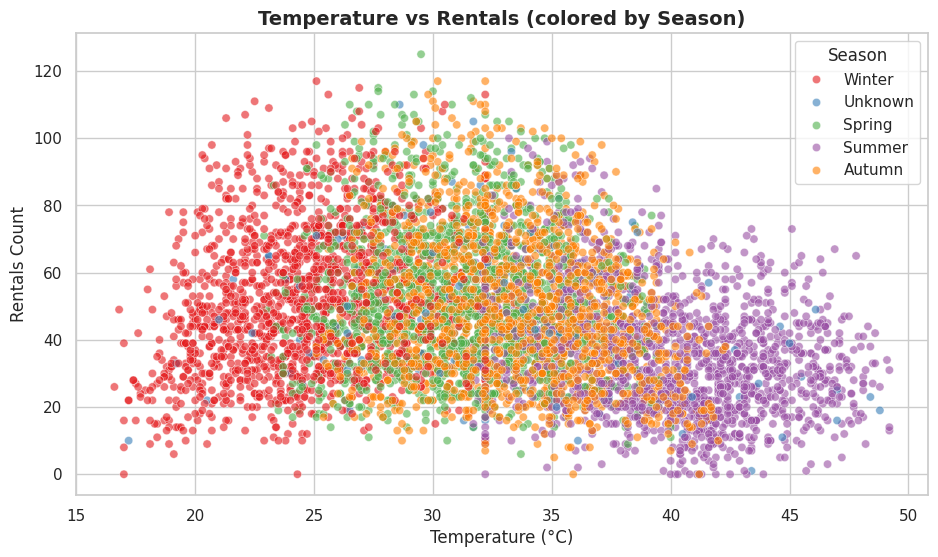

In [ ]:
# TODO: Scatter plot with hue=Season
plt.figure(figsize=(11, 6))
sns.scatterplot(x='Temperature_C', y='Rentals_Count', hue='Season',
                data=df, alpha=0.6, palette='Set1')
plt.title('Temperature vs Rentals (colored by Season)', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Rentals Count')
plt.legend(title='Season')
plt.show()

## 4.7 Rentals by Day of Week

**Task:** Show average rentals per day of the week. Is there a weekend effect (Friday/Saturday in Saudi Arabia)?


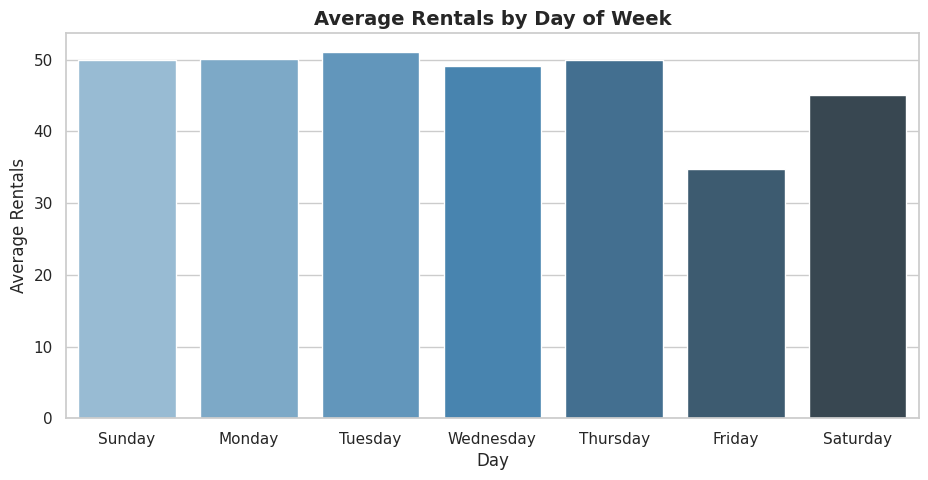

In [ ]:
# TODO: Bar plot of average Rentals_Count by Day_of_Week
# Hint: order the days correctly (Sunday through Saturday)
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_avg = df.groupby('Day_of_Week')['Rentals_Count'].mean().reindex(day_order)

plt.figure(figsize=(11, 5))
sns.barplot(x=day_avg.index, y=day_avg.values, palette='Blues_d')
plt.title('Average Rentals by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Rentals')
plt.show()

## 4.8 Holiday Effect

**Task:** Compare `Rentals_Count` for holidays vs non-holidays using a boxplot or violin plot.


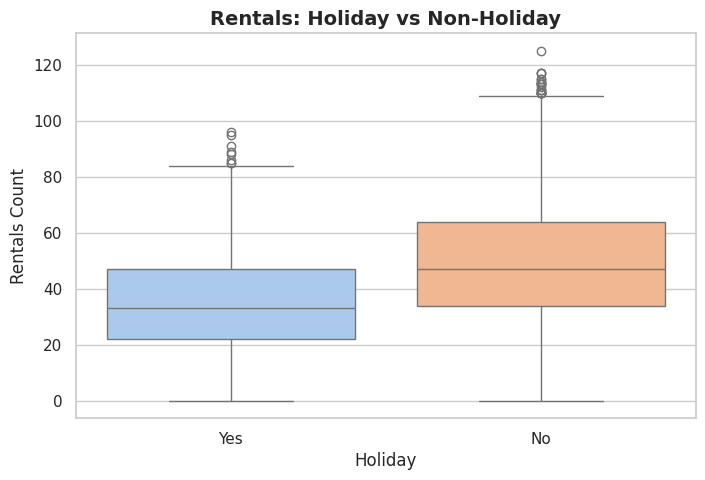

Average rentals — Holiday: 35.58, Non-Holiday: 49.88


In [ ]:
# TODO: Boxplot or violin plot comparing Holiday Yes vs No
plt.figure(figsize=(8, 5))
sns.boxplot(x='Holiday', y='Rentals_Count', data=df, palette='pastel')
plt.title('Rentals: Holiday vs Non-Holiday', fontsize=14, fontweight='bold')
plt.xlabel('Holiday')
plt.ylabel('Rentals Count')
plt.show()

print("Average rentals — Holiday: {:.2f}, Non-Holiday: {:.2f}".format(
    df[df['Holiday']=='Yes']['Rentals_Count'].mean(),
    df[df['Holiday']=='No']['Rentals_Count'].mean()
))

---

# Part 5: Feature Engineering

**Tasks**

1. Extract `Month` and `Day` from the `Date` column
2. Create `Is_Peak_Hour` — 1 if Hour is 9–11 or 16–19, else 0
3. Create `Temperature_Bin` — `Cool` (< 25), `Warm` (25–35), `Hot` (> 35)
4. Create `Is_Weekend` — 1 if Friday or Saturday, else 0


In [ ]:
# TODO: Extract Month from Date
df['Month'] = df['Date'].dt.month


In [ ]:
# TODO: Extract Day from Date
df['Day'] = df['Date'].dt.day


In [ ]:
# TODO: Create Is_Peak_Hour column
df['Is_Peak_Hour'] = df['Hour'].apply(
    lambda h: 1 if (9 <= h <= 11) or (16 <= h <= 19) else 0
)


In [ ]:
# TODO: Create Temperature_Bin column
# Hint: use pd.cut() or a custom function with .apply()
def categorize_temp(t):
    if t < 25:
        return 'Cool'
    elif t <= 35:
        return 'Warm'
    else:
        return 'Hot'

df['Temperature_Bin'] = df['Temperature_C'].apply(categorize_temp)
print(df['Temperature_Bin'].value_counts())


Temperature_Bin
Warm    3283
Hot     2166
Cool     918
Name: count, dtype: int64


In [ ]:
# TODO: Create Is_Weekend column
# Hint: Date.dt.weekday — Friday=4, Saturday=5
df['Is_Weekend'] = df['Date'].dt.weekday.isin([4, 5]).astype(int)
print("Weekend rows:", df['Is_Weekend'].sum())


Weekend rows: 1832


In [ ]:
# Verify
print(df[['Date', 'Hour', 'Month', 'Day', 'Is_Peak_Hour', 'Temperature_Bin', 'Is_Weekend']].head(10))


        Date  Hour  Month  Day  Is_Peak_Hour Temperature_Bin  Is_Weekend
0 2023-01-01     9      1    1             1            Cool           0
1 2023-01-01    10      1    1             1            Warm           0
2 2023-01-01    14      1    1             0            Warm           0
3 2023-01-01    16      1    1             1            Warm           0
4 2023-01-01    18      1    1             1            Warm           0
5 2023-01-01    19      1    1             1            Warm           0
6 2023-01-01    20      1    1             0            Cool           0
7 2023-01-02     8      1    2             0            Cool           0
8 2023-01-02     9      1    2             1            Cool           0
9 2023-01-02    10      1    2             1            Cool           0


---

# Part 6: Encoding and Preparing for ML

**Tasks**

1. Drop the `Date` column (we already extracted Month and Day)
2. Encode categorical variables — use `pd.get_dummies()` for one-hot encoding (or `LabelEncoder` where appropriate)
3. Define feature matrix `X` and target `y`
4. Split into 80% train / 20% test
5. Apply `StandardScaler` to features


In [ ]:
# TODO: Drop the Date column
df_ml = df.drop(columns=['Date', 'Functioning_Day'])
print("Columns for ML:", df_ml.columns.tolist())


Columns for ML: ['Hour', 'Rentals_Count', 'Temperature_C', 'Humidity_pct', 'Wind_Speed_ms', 'Visibility_m', 'Solar_Radiation_MJm2', 'Rainfall_mm', 'Season', 'Holiday', 'Library_Branch', 'Top_Category', 'Membership_Type', 'Day_of_Week', 'Month', 'Day', 'Is_Peak_Hour', 'Temperature_Bin', 'Is_Weekend']


In [ ]:
# TODO: One-hot encode categorical columns using pd.get_dummies()
categorical_cols = ['Season', 'Holiday', 'Library_Branch', 'Top_Category',
                    'Membership_Type', 'Day_of_Week', 'Temperature_Bin']

df_encoded = pd.get_dummies(df_ml, columns=categorical_cols, drop_first=True)

# Convert any boolean columns from get_dummies to int
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after encoding:", df_encoded.shape)


Shape after encoding: (6367, 39)


In [ ]:
# TODO: Define X (everything except Rentals_Count) and y (Rentals_Count)
X = df_encoded.drop(columns=['Rentals_Count'])
y = df_encoded['Rentals_Count']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (6367, 38)
Target shape: (6367,)


In [ ]:
# TODO: Train/test split (80/20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (5093, 38)
Test set: (1274, 38)


In [ ]:
# TODO: Initialize StandardScaler, fit on train, transform both train and test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("Train mean ~ 0:", X_train_scaled.mean().round(4))
print("Train std ~ 1: ", X_train_scaled.std().round(4))

Scaling done.
Train mean ~ 0: -0.0
Train std ~ 1:  1.0


---

# Part 7: Model Building and Evaluation

We will build **4 different models** and compare their performance.

### Evaluation Metrics

- **R² (R-squared):** how much variance is explained by the model
- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual
- **RMSE (Root Mean Squared Error):** penalizes large errors more heavily than MAE


## 7.1 Model 1 — Linear Regression

**Tasks**

1. Initialize and train a Linear Regression model
2. Make predictions on the test set
3. Calculate R², MAE, RMSE
4. Plot Actual vs Predicted scatter plot


In [ ]:
# TODO: Initialize Linear Regression model
def evaluate_model(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{name}")
    print("-" * 40)
    print(f"R² Score: {r2:.4f}")
    print(f"MAE:      {mae:.4f}")
    print(f"RMSE:     {rmse:.4f}")
    return r2, mae, rmse

def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, color='steelblue')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.title(f'Actual vs Predicted — {title}', fontsize=13, fontweight='bold')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.show()

In [ ]:
# TODO: Train the model on X_train_scaled, y_train
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
# TODO: Predict on X_test_scaled
y_pred_lr = lr_model.predict(X_test_scaled)

In [ ]:
# TODO: Calculate and print R2, MAE, RMSE
r2_lr, mae_lr, rmse_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)


Linear Regression
----------------------------------------
R² Score: 0.8628
MAE:      6.0733
RMSE:     7.7902


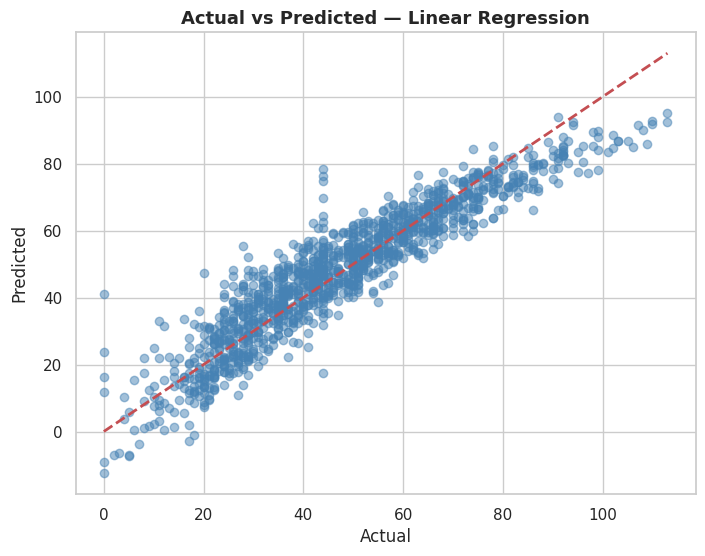

In [ ]:
# TODO: Plot Actual vs Predicted
# plt.scatter(y_test, y_pred_lr, alpha=0.5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plot_actual_vs_predicted(y_test, y_pred_lr, "Linear Regression")

## 7.2 Model 2 — Decision Tree Regressor

**Tasks**

1. Initialize a Decision Tree Regressor with `max_depth=10` and `random_state=42`
2. Train, predict, evaluate
3. Plot Actual vs Predicted
4. Plot the top 10 most important features


In [ ]:
# TODO: Initialize Decision Tree Regressor
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=10, random_state=42)

In [ ]:
# TODO: Train, predict, calculate R2/MAE/RMSE
y_pred_dt = dt_model.predict(X_test_scaled)
r2_dt, mae_dt, rmse_dt = evaluate_model("Decision Tree", y_test, y_pred_dt)


Decision Tree
----------------------------------------
R² Score: 0.8367
MAE:      6.3386
RMSE:     8.4973


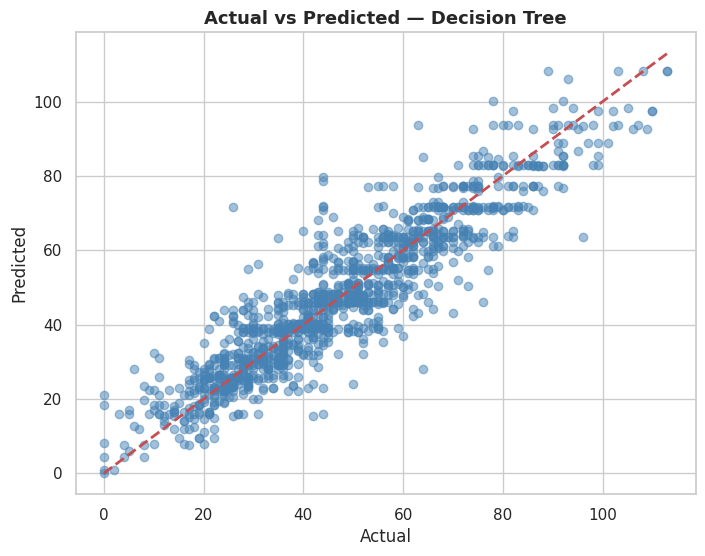

In [ ]:
# TODO: Plot Actual vs Predicted
plot_actual_vs_predicted(y_test, y_pred_dt, "Decision Tree")

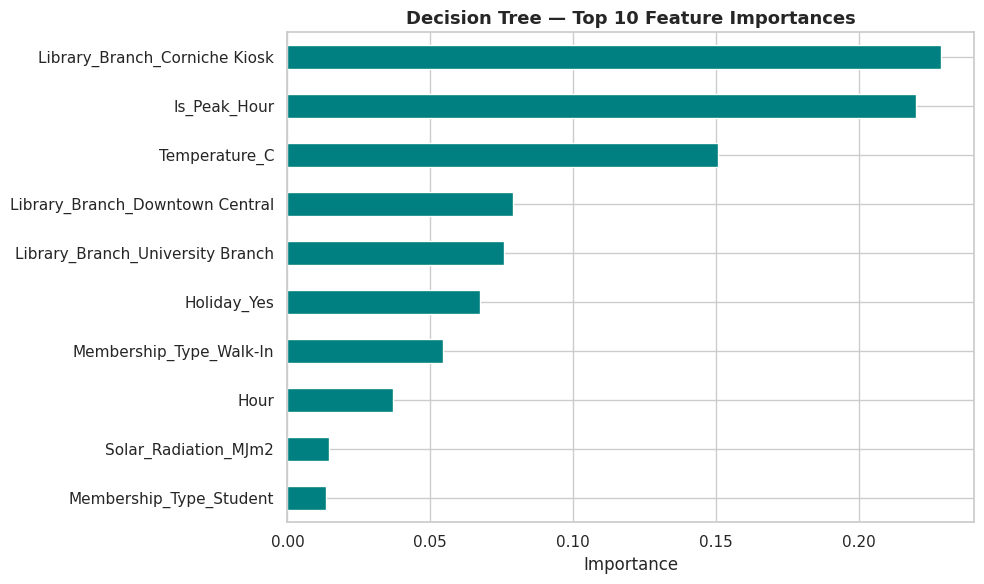

In [ ]:
# TODO: Plot top 10 feature importances
# Hint: model.feature_importances_ gives you the values
# Use a horizontal bar chart sorted by importance
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top10_dt = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top10_dt.plot(kind='barh', color='teal')
plt.title('Decision Tree — Top 10 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7.3 Model 3 — Random Forest Regressor

**Tasks**

1. Initialize a Random Forest with `n_estimators=100`, `max_depth=15`, `random_state=42`
2. Train, predict, evaluate
3. Plot Actual vs Predicted
4. Plot top 10 feature importances


In [ ]:
# TODO: Initialize Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)


RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [ ]:
# TODO: Train, predict, calculate R2/MAE/RMSE
y_pred_rf = rf_model.predict(X_test_scaled)
r2_rf, mae_rf, rmse_rf = evaluate_model("Random Forest", y_test, y_pred_rf)



Random Forest
----------------------------------------
R² Score: 0.9135
MAE:      4.4948
RMSE:     6.1836


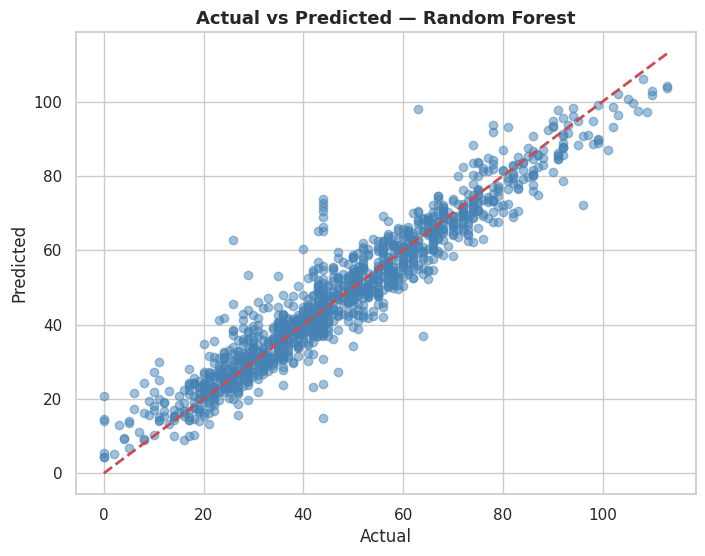

In [ ]:
# TODO: Plot Actual vs Predicted
plot_actual_vs_predicted(y_test, y_pred_rf, "Random Forest")


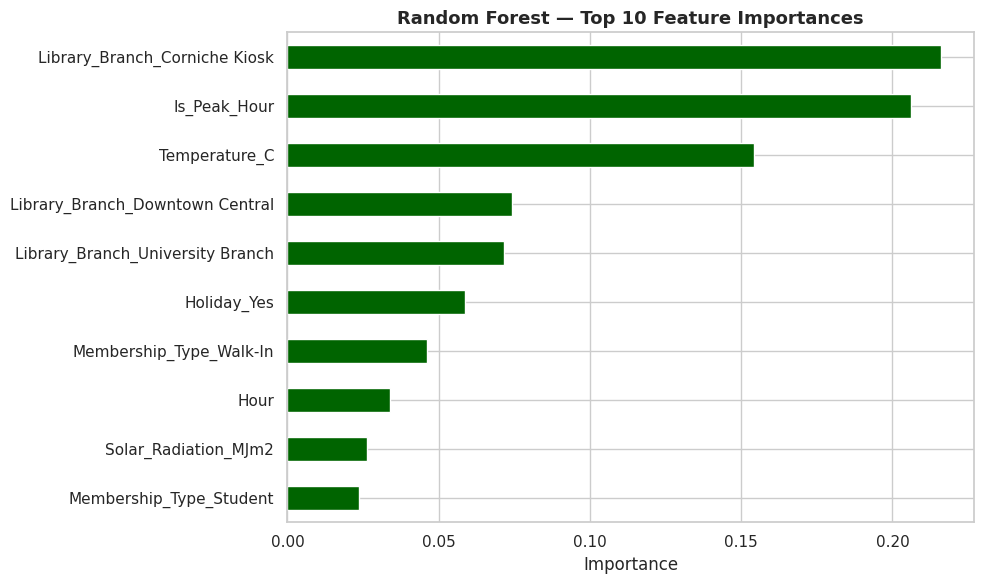

In [ ]:
# TODO: Plot top 10 feature importances
importances_rf = pd.Series(rf_model.feature_importances_, index=X.columns)
top10_rf = importances_rf.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
top10_rf.plot(kind='barh', color='darkgreen')
plt.title('Random Forest — Top 10 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## 7.4 Model 4 — Neural Network

A neural network is a model loosely inspired by how the brain processes information. We will build a very simple one with just one hidden layer.

**Tasks**

1. Build a simple Sequential neural network with one hidden layer of 32 neurons (ReLU activation) and a single output neuron
2. Compile with `optimizer='adam'` and `loss='mse'`
3. Train for 50 epochs with `batch_size=32`
4. Predict on the test set and evaluate with R², MAE, RMSE


In [ ]:
# TODO: Build a simple Neural Network with 1 hidden layer
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Input
# Layer 1 (hidden): Dense(32, activation='relu')
# Layer 2 (output): Dense(1)
model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])


In [ ]:
# TODO: Compile the model with optimizer='adam' and loss='mse'
model_nn.compile(optimizer='adam', loss='mse')

In [ ]:
# TODO: Train the model for 50 epochs with batch_size=32
model_nn.fit(X_train_scaled, y_train, epochs=50, batch_size=32, verbose=0)
print("Training complete.")


Training complete.


In [ ]:
# TODO: Predict on X_test_scaled
# Hint: model.predict() returns 2D, use .flatten() to make it 1D
y_pred_nn = model_nn.predict(X_test_scaled, verbose=0).flatten()

In [ ]:
# TODO: Calculate and print R2, MAE, RMSE
r2_nn, mae_nn, rmse_nn = evaluate_model("Neural Network", y_test, y_pred_nn)


Neural Network
----------------------------------------
R² Score: 0.9188
MAE:      4.4188
RMSE:     5.9907


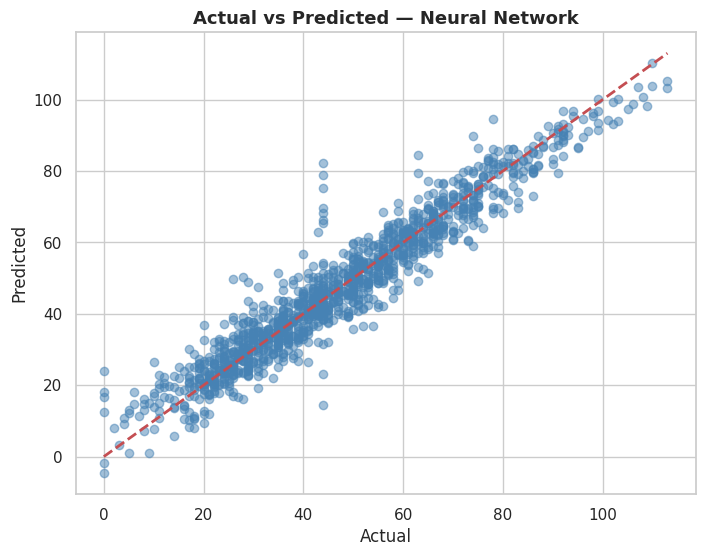

In [ ]:
# TODO: Plot Actual vs Predicted
plot_actual_vs_predicted(y_test, y_pred_nn, "Neural Network")

---

# Part 8: Model Comparison

**Tasks**

1. Build a summary DataFrame comparing all 4 models on R², MAE, RMSE
2. Plot a bar chart comparing R² scores
3. Write a short conclusion (3–5 sentences)


In [ ]:
# TODO: Build a comparison DataFrame
# Columns: Model, R2, MAE, RMSE
# Rows: Linear Regression, Decision Tree, Random Forest, Neural Network
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Neural Network'],
    'R²':   [r2_lr,  r2_dt,  r2_rf,  r2_nn],
    'MAE':  [mae_lr, mae_dt, mae_rf, mae_nn],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_nn]
}).round(4)

In [ ]:
# TODO: Display the comparison table
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results.to_string(index=False))
print("=" * 60)
print(f"\nBest model by R²:   {results.loc[results['R²'].idxmax(), 'Model']}")
print(f"Best model by MAE:  {results.loc[results['MAE'].idxmin(), 'Model']}")
print(f"Best model by RMSE: {results.loc[results['RMSE'].idxmin(), 'Model']}")

MODEL COMPARISON
            Model     R²    MAE   RMSE
Linear Regression 0.8628 6.0733 7.7902
    Decision Tree 0.8367 6.3386 8.4973
    Random Forest 0.9135 4.4948 6.1836
   Neural Network 0.9188 4.4188 5.9907

Best model by R²:   Neural Network
Best model by MAE:  Neural Network
Best model by RMSE: Neural Network


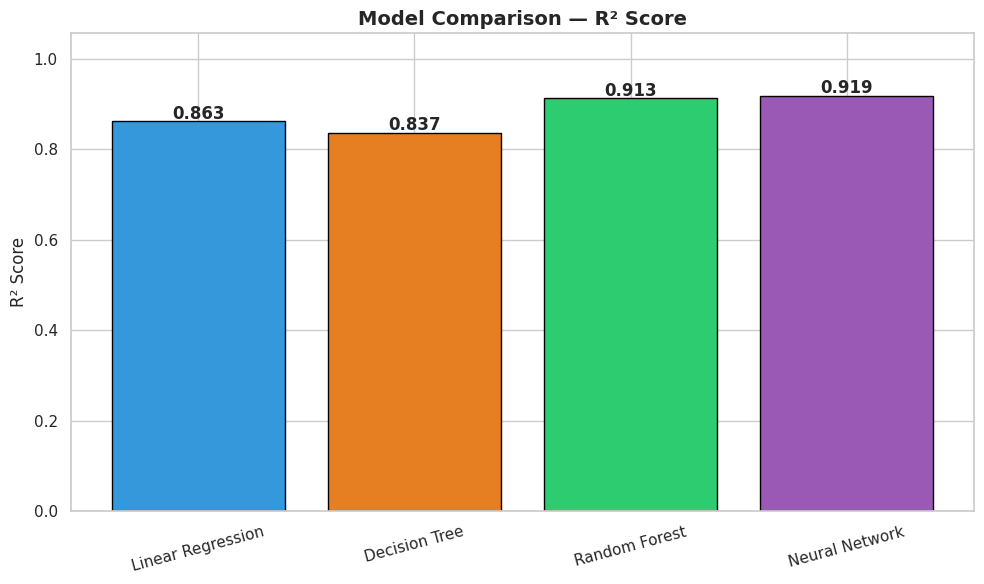

In [ ]:
# TODO: Bar chart of R2 scores for all 4 models
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
bars = plt.bar(results['Model'], results['R²'], color=colors, edgecolor='black')

for bar, val in zip(bars, results['R²']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold')

plt.title('Model Comparison — R² Score', fontsize=14, fontweight='bold')
plt.ylabel('R² Score')
plt.ylim(0, max(results['R²']) * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Conclusion

Write 3–5 sentences answering:

1. Which model performed best on this dataset?
2. Why do you think that model outperformed the others?
3. Which features were most important for predicting rentals?
4. What would you recommend to library management based on your findings?

*Write your answer here:*


---

# Submission Checklist

- [ ] Data is fully cleaned (no missing values, no negative rentals, no duplicates)
- [ ] All categorical columns are consistently formatted
- [ ] At least 6 EDA visualizations are completed with titles and labels
- [ ] Feature engineering: `Month`, `Day`, `Is_Peak_Hour`, `Temperature_Bin`, `Is_Weekend` created
- [ ] Categorical variables are encoded
- [ ] Data is split into train/test and scaled
- [ ] **Model 1 — Linear Regression** trained and evaluated
- [ ] **Model 2 — Decision Tree** trained and evaluated with feature importance
- [ ] **Model 3 — Random Forest** trained and evaluated with feature importance
- [ ] **Model 4 — Neural Network** trained and evaluated
- [ ] All 4 models compared in a summary table and bar chart
- [ ] Conclusion written with recommendations
